In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

print("✓ All libraries loaded!")

Matplotlib is building the font cache; this may take a moment.


✓ All libraries loaded!


In [2]:
df = pd.read_csv('../data/data.csv')

print("Shape:", df.shape)
print("First look at data:")
df.head()

Shape: (6819, 96)
First look at data:


,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


In [3]:
missing = df.isnull().sum().sort_values(ascending=False)
print("Columns with missing values:")
print(missing[missing > 0])
print("\nTotal missing values:", df.isnull().sum().sum())

Columns with missing values:
Series([], dtype: int64)

Total missing values: 0


In [4]:
print("Bankruptcy Count:")
print(df['Bankrupt?'].value_counts())

print("\nPercentage Split:")
print(df['Bankrupt?'].value_counts(normalize=True).mul(100).round(2))

Bankruptcy Count:
Bankrupt?
0    6599
1     220
Name: count, dtype: int64

Percentage Split:
Bankrupt?
0    96.77
1     3.23
Name: proportion, dtype: float64


In [5]:
conn = sqlite3.connect('../data/financials.db')

df.to_sql('companies', conn, if_exists='replace', index=False)

print("✓ Data saved to database!")
print("Total rows saved:", pd.read_sql_query("SELECT COUNT(*) as total FROM companies", conn).iloc[0,0])

conn.close()

✓ Data saved to database!
Total rows saved: 6819


In [6]:
conn = sqlite3.connect('../data/financials.db')

query = """
SELECT 
    "Bankrupt?" AS status,
    COUNT(*) AS total_companies,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM companies), 2) AS percentage
FROM companies
GROUP BY "Bankrupt?"
"""

result = pd.read_sql_query(query, conn)
conn.close()

print(result)

   status  total_companies  percentage
0       0             6599       96.77
1       1              220        3.23


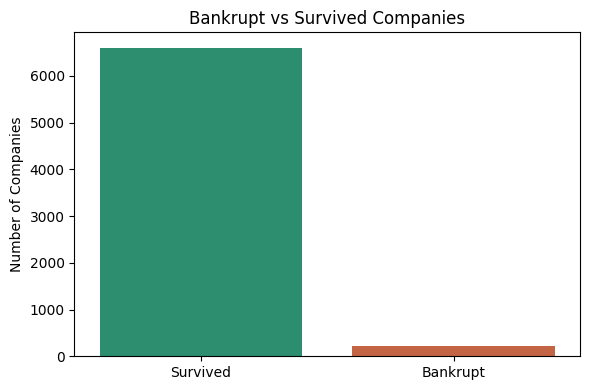

✓ Chart saved to dashboards folder!


In [8]:
import os
os.makedirs('../dashboards', exist_ok=True)

plt.figure(figsize=(6, 4))
sns.countplot(x='Bankrupt?', data=df, hue='Bankrupt?', palette={0: '#1D9E75', 1: '#D85A30'}, legend=False)
plt.title('Bankrupt vs Survived Companies')
plt.xticks([0, 1], ['Survived', 'Bankrupt'])
plt.xlabel('')
plt.ylabel('Number of Companies')
plt.tight_layout()
plt.savefig('../dashboards/bankruptcy_distribution.png', dpi=150)
plt.show()

print("✓ Chart saved to dashboards folder!")

## Phase 2 - Exploratory Data Analysis & Feature Engineering

In [10]:
# Use column positions instead of names to avoid spacing issues
col1 = df.columns[0]   # Bankrupt?
col2 = df.columns[1]   # ROA
col3 = df.columns[47]  # Debt ratio
col4 = df.columns[48]  # Net worth

print("Columns we are analysing:")
print("0:", col1)
print("1:", col2)
print("3:", col3)
print("4:", col4)

stats = df[[col1, col2, col3, col4]].describe().round(4)
print("\nBasic Statistics:")
print(stats)

Columns we are analysing:
0: Bankrupt?
1:  ROA(C) before interest and depreciation before interest
3:  Average Collection Days
4:  Inventory Turnover Rate (times)

Basic Statistics:
       Bankrupt?   ROA(C) before interest and depreciation before interest  \
count  6819.0000                                          6819.0000          
mean      0.0323                                             0.5052          
std       0.1767                                             0.0607          
min       0.0000                                             0.0000          
25%       0.0000                                             0.4765          
50%       0.0000                                             0.5027          
75%       0.0000                                             0.5356          
max       1.0000                                             1.0000          

        Average Collection Days   Inventory Turnover Rate (times)  
count              6.819000e+03                

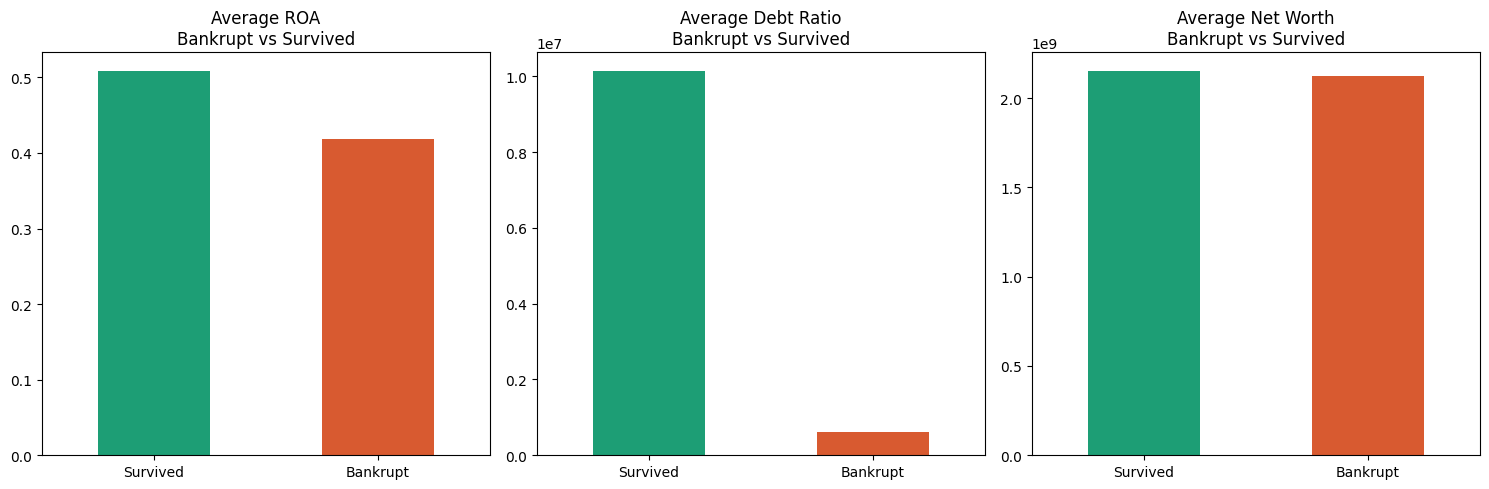

✓ Comparison charts saved!


In [11]:
col_roa = df.columns[1]   # ROA
col_debt = df.columns[47] # Debt ratio
col_nw = df.columns[48]   # Net worth

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Chart 1 - ROA comparison
df.groupby('Bankrupt?')[col_roa].mean().plot(
    kind='bar', ax=axes[0], color=['#1D9E75', '#D85A30'])
axes[0].set_title('Average ROA\nBankrupt vs Survived')
axes[0].set_xticklabels(['Survived', 'Bankrupt'], rotation=0)
axes[0].set_xlabel('')

# Chart 2 - Debt ratio comparison
df.groupby('Bankrupt?')[col_debt].mean().plot(
    kind='bar', ax=axes[1], color=['#1D9E75', '#D85A30'])
axes[1].set_title('Average Debt Ratio\nBankrupt vs Survived')
axes[1].set_xticklabels(['Survived', 'Bankrupt'], rotation=0)
axes[1].set_xlabel('')

# Chart 3 - Net worth comparison
df.groupby('Bankrupt?')[col_nw].mean().plot(
    kind='bar', ax=axes[2], color=['#1D9E75', '#D85A30'])
axes[2].set_title('Average Net Worth\nBankrupt vs Survived')
axes[2].set_xticklabels(['Survived', 'Bankrupt'], rotation=0)
axes[2].set_xlabel('')

plt.tight_layout()
plt.savefig('../dashboards/comparison_charts.png', dpi=150)
plt.show()

print("✓ Comparison charts saved!")

In [12]:
# Get exact column names
col_roa = df.columns[1]
col_debt = df.columns[47]
col_nw = df.columns[48]
col_current = df.columns[45]
col_profit = df.columns[6]

# ── Create NEW powerful features ──────────────
# 1. Risk Score — higher = more risky
df['risk_score'] = (df[col_debt] * 2) - (df[col_roa] * 3) - df[col_nw]

# 2. Financial Health Score — higher = more healthy  
df['health_score'] = (df[col_roa] * 3) + df[col_nw] - (df[col_debt] * 2)

# 3. Profit to Debt Ratio
df['profit_debt_ratio'] = df[col_profit] / (df[col_debt] + 0.0001)

print("✓ New features created successfully!")
print("\nNew columns added:")
print("1. risk_score")
print("2. health_score")  
print("3. profit_debt_ratio")

print("\nAverage Risk Score:")
print(df.groupby('Bankrupt?')['risk_score'].mean().round(4))
print("\nAverage Health Score:")
print(df.groupby('Bankrupt?')['health_score'].mean().round(4))

✓ New features created successfully!

New columns added:
1. risk_score
2. health_score
3. profit_debt_ratio

Average Risk Score:
Bankrupt?
0   -2.129656e+09
1   -2.123388e+09
Name: risk_score, dtype: float64

Average Health Score:
Bankrupt?
0    2.129656e+09
1    2.123388e+09
Name: health_score, dtype: float64


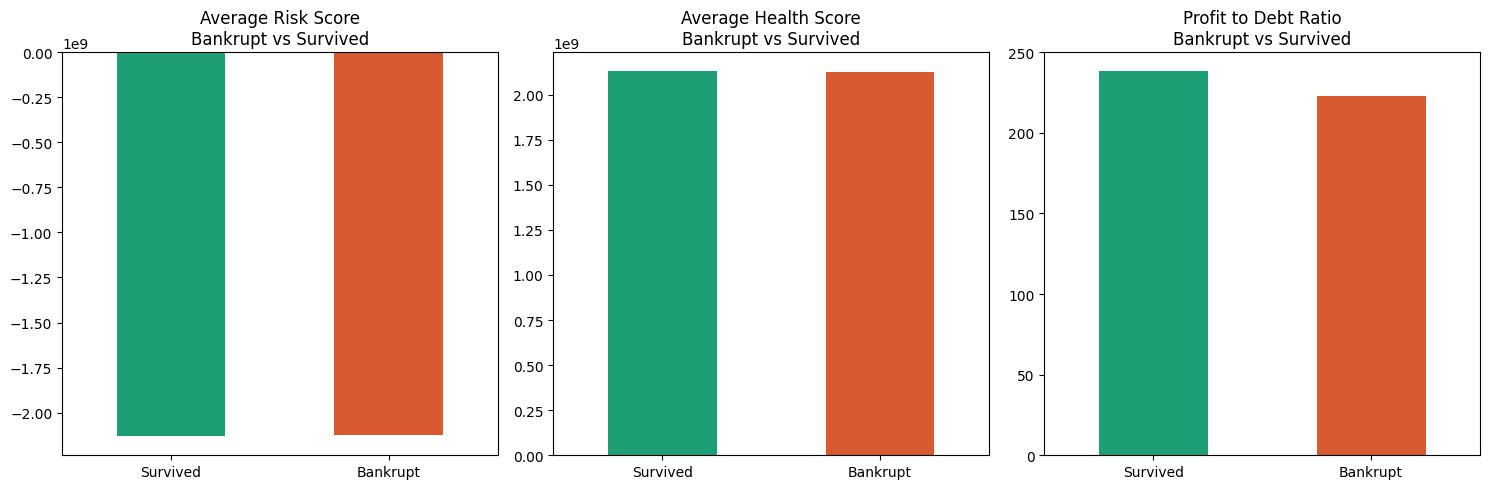

✓ Feature charts saved!


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Chart 1 - Risk Score
df.groupby('Bankrupt?')['risk_score'].mean().plot(
    kind='bar', ax=axes[0], color=['#1D9E75', '#D85A30'])
axes[0].set_title('Average Risk Score\nBankrupt vs Survived')
axes[0].set_xticklabels(['Survived', 'Bankrupt'], rotation=0)
axes[0].set_xlabel('')

# Chart 2 - Health Score
df.groupby('Bankrupt?')['health_score'].mean().plot(
    kind='bar', ax=axes[1], color=['#1D9E75', '#D85A30'])
axes[1].set_title('Average Health Score\nBankrupt vs Survived')
axes[1].set_xticklabels(['Survived', 'Bankrupt'], rotation=0)
axes[1].set_xlabel('')

# Chart 3 - Profit Debt Ratio
df.groupby('Bankrupt?')['profit_debt_ratio'].mean().plot(
    kind='bar', ax=axes[2], color=['#1D9E75', '#D85A30'])
axes[2].set_title('Profit to Debt Ratio\nBankrupt vs Survived')
axes[2].set_xticklabels(['Survived', 'Bankrupt'], rotation=0)
axes[2].set_xlabel('')

plt.tight_layout()
plt.savefig('../dashboards/feature_charts.png', dpi=150)
plt.show()

print("✓ Feature charts saved!")

In [15]:
conn = sqlite3.connect('../data/financials.db')

df.to_sql('companies', conn, if_exists='replace', index=False)

print("Done! Updated data saved to database!")
print("Total columns now:", len(df.columns))
print("Original columns: 96")
print("New columns added: 3")
print("\nYour database now has ALL features including:")
print("  - risk_score")
print("  - health_score")
print("  - profit_debt_ratio")

conn.close()

Done! Updated data saved to database!
Total columns now: 99
Original columns: 96
New columns added: 3

Your database now has ALL features including:
  - risk_score
  - health_score
  - profit_debt_ratio


## Phase 3 - Machine Learning Model (XGBoost)

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import numpy as np

print("All ML libraries loaded!")

All ML libraries loaded!


In [17]:
# Separate features (X) and target (y)
X = df.drop('Bankrupt?', axis=1)
y = df['Bankrupt?']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nBankrupt cases:", y.sum())
print("Survived cases:", (y == 0).sum())

Features shape: (6819, 98)
Target shape: (6819,)

Bankrupt cases: 220
Survived cases: 6599


In [18]:
# SMOTE creates fake bankrupt samples to balance the dataset
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("Before SMOTE:")
print("  Bankrupt:", y.sum(), "| Survived:", (y==0).sum())

print("\nAfter SMOTE:")
print("  Bankrupt:", y_resampled.sum(), "| Survived:", (y_resampled==0).sum())
print("\nNow both classes are balanced!")

Before SMOTE:
  Bankrupt: 220 | Survived: 6599

After SMOTE:
  Bankrupt: 6599 | Survived: 6599

Now both classes are balanced!


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, 
    test_size=0.2,      # 20% for testing
    random_state=42     # same split every time
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)
print("\n80% of data used to TRAIN the model")
print("20% of data used to TEST the model")

Training data: (10558, 98)
Testing data: (2640, 98)

80% of data used to TRAIN the model
20% of data used to TEST the model


In [20]:
model = XGBClassifier(
    n_estimators=100,    # 100 decision trees
    max_depth=5,         # how deep each tree goes
    learning_rate=0.1,   # how fast it learns
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully!")
print("Trees built:", model.n_estimators)

Model trained successfully!
Trees built: 100


In [21]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred) * 100

print("Model Accuracy:", round(accuracy, 2), "%")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred, 
      target_names=['Survived', 'Bankrupt']))

Model Accuracy: 98.37 %

Detailed Report:
              precision    recall  f1-score   support

    Survived       1.00      0.97      0.98      1334
    Bankrupt       0.97      1.00      0.98      1306

    accuracy                           0.98      2640
   macro avg       0.98      0.98      0.98      2640
weighted avg       0.98      0.98      0.98      2640



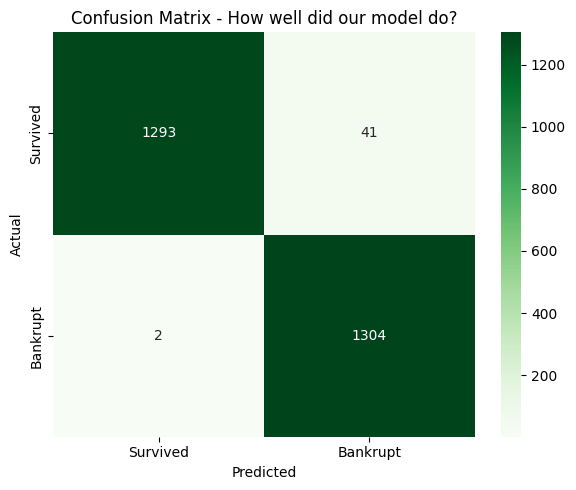

Confusion matrix saved!


In [22]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Survived', 'Bankrupt'],
            yticklabels=['Survived', 'Bankrupt'])
plt.title('Confusion Matrix - How well did our model do?')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../dashboards/confusion_matrix.png', dpi=150)
plt.show()

print("Confusion matrix saved!")

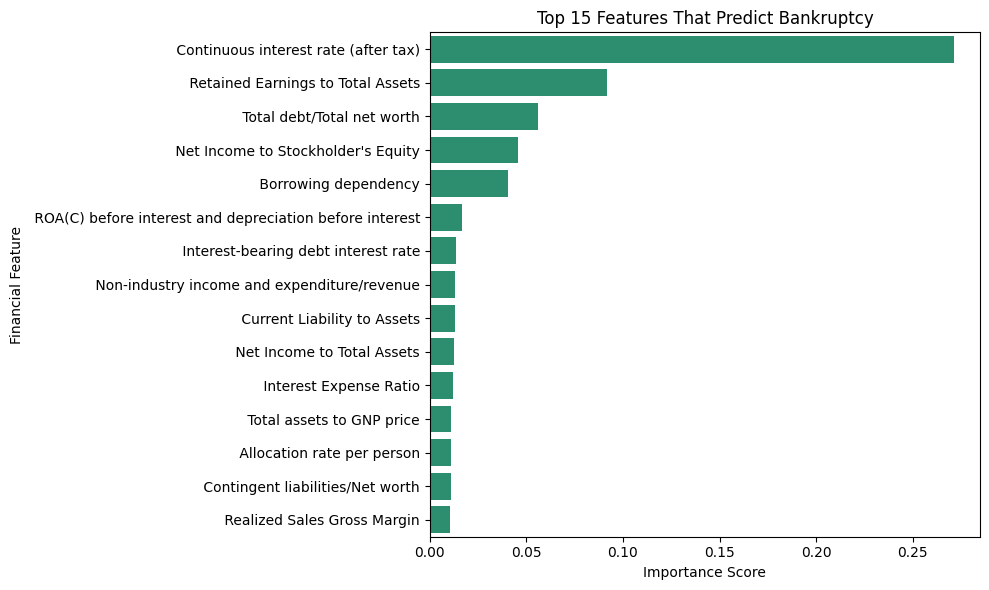

Top 3 most important features:
 -  Continuous interest rate (after tax) : 0.2712
 -  Retained Earnings to Total Assets : 0.0915
 -  Total debt/Total net worth : 0.0561


In [23]:
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=importance, color='#1D9E75')
plt.title('Top 15 Features That Predict Bankruptcy')
plt.xlabel('Importance Score')
plt.ylabel('Financial Feature')
plt.tight_layout()
plt.savefig('../dashboards/feature_importance.png', dpi=150)
plt.show()

print("Top 3 most important features:")
for i, row in importance.head(3).iterrows():
    print(" -", row['feature'], ":", round(row['importance'], 4))

In [24]:
import pickle
import os

os.makedirs('../model', exist_ok=True)

with open('../model/bankruptcy_model.pkl', 'wb') as f:
    pickle.dump(model, f)

print("Model saved successfully!")
print("Location: model/bankruptcy_model.pkl")
print("This model can now predict bankruptcy for ANY new company!")

Model saved successfully!
Location: model/bankruptcy_model.pkl
This model can now predict bankruptcy for ANY new company!


In [25]:
# Take one real company from dataset and predict
sample = X_test.iloc[0:1]
actual = y_test.iloc[0]
prediction = model.predict(sample)[0]
probability = model.predict_proba(sample)[0]

print("Testing on a real company from dataset:")
print("Actual status:    ", "BANKRUPT" if actual == 1 else "SURVIVED")
print("Model prediction: ", "BANKRUPT" if prediction == 1 else "SURVIVED")
print("\nModel confidence:")
print("  Survival probability: ", round(probability[0] * 100, 2), "%")
print("  Bankruptcy probability:", round(probability[1] * 100, 2), "%")

if actual == prediction:
    print("\nCorrect prediction!")
else:
    print("\nWrong prediction this time!")

Testing on a real company from dataset:
Actual status:     SURVIVED
Model prediction:  SURVIVED

Model confidence:
  Survival probability:  76.61 %
  Bankruptcy probability: 23.39 %

Correct prediction!


## Phase 4 - SHAP Explainability

In [26]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

print("SHAP explainer created successfully!")
print("Explaining predictions for:", X_test.shape[0], "companies")

SHAP explainer created successfully!
Explaining predictions for: 2640 companies


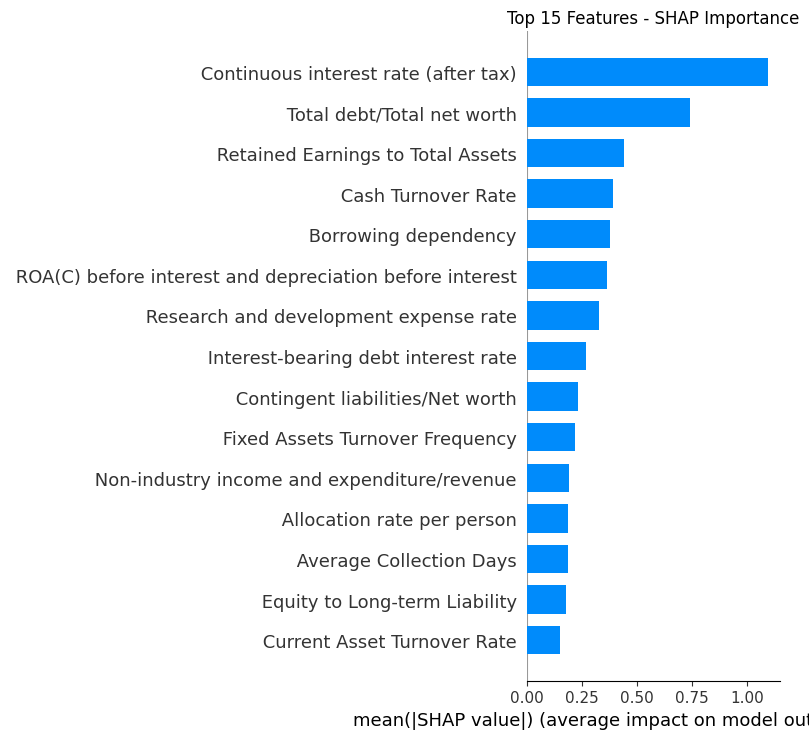

SHAP summary plot saved!


In [27]:
plt.figure()
shap.summary_plot(shap_values, X_test, 
                  plot_type="bar",
                  max_display=15,
                  show=False)
plt.title("Top 15 Features - SHAP Importance")
plt.tight_layout()
plt.savefig('../dashboards/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print("SHAP summary plot saved!")

In [28]:
# Pick one company and explain why model predicted bankruptcy or survival
idx = 0
company_shap = shap_values[idx]
company_features = X_test.iloc[idx]

# Get top 5 reasons for prediction
feature_impact = pd.DataFrame({
    'feature': X_test.columns,
    'shap_value': company_shap
}).sort_values('shap_value', key=abs, ascending=False).head(5)

prediction = model.predict(X_test.iloc[idx:idx+1])[0]
print("Company prediction:", "BANKRUPT" if prediction == 1 else "SURVIVED")
print("\nTop 5 reasons WHY:")
for i, row in feature_impact.iterrows():
    direction = "increases" if row['shap_value'] > 0 else "decreases"
    print(f"  - {row['feature'][:40]} {direction} bankruptcy risk")

Company prediction: SURVIVED

Top 5 reasons WHY:
  -  Total debt/Total net worth decreases bankruptcy risk
  -  Continuous interest rate (after tax) increases bankruptcy risk
  -  Average Collection Days increases bankruptcy risk
  -  Inventory Turnover Rate (times) decreases bankruptcy risk
  -  Revenue per person decreases bankruptcy risk


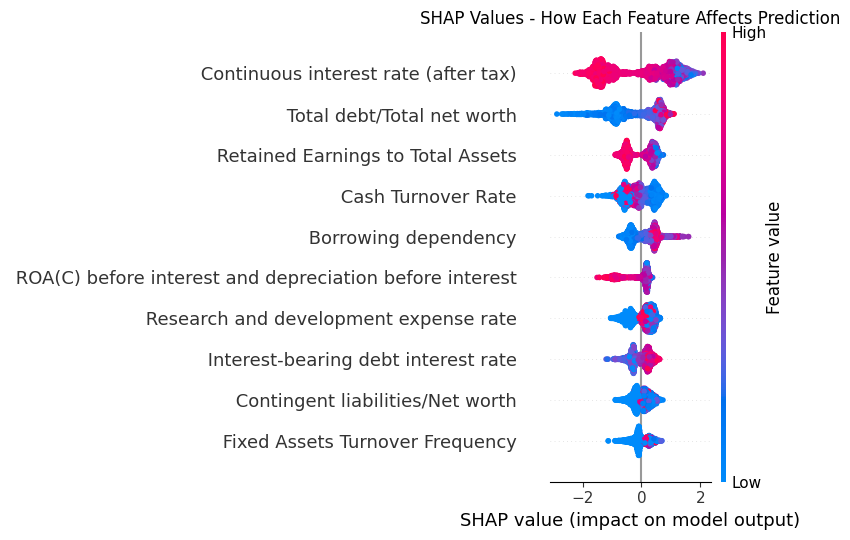

SHAP dot plot saved!


In [29]:
plt.figure()
shap.summary_plot(shap_values, X_test,
                  max_display=10,
                  show=False)
plt.title("SHAP Values - How Each Feature Affects Prediction")
plt.tight_layout()
plt.savefig('../dashboards/shap_dot_plot.png', dpi=150, bbox_inches='tight')
plt.show()

print("SHAP dot plot saved!")

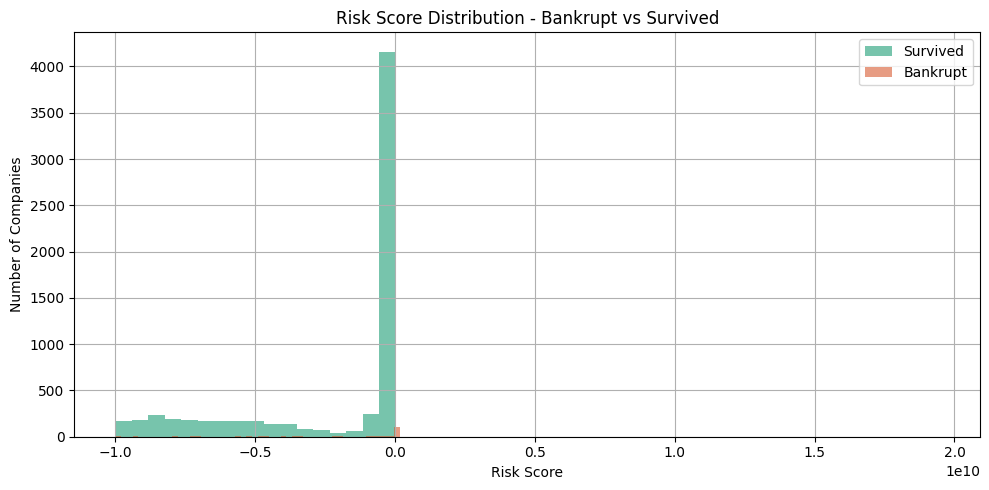

Risk distribution chart saved!


In [30]:
plt.figure(figsize=(10, 5))
df[df['Bankrupt?']==0]['risk_score'].hist(
    bins=50, alpha=0.6, color='#1D9E75', label='Survived')
df[df['Bankrupt?']==1]['risk_score'].hist(
    bins=50, alpha=0.6, color='#D85A30', label='Bankrupt')
plt.xlabel('Risk Score')
plt.ylabel('Number of Companies')
plt.title('Risk Score Distribution - Bankrupt vs Survived')
plt.legend()
plt.tight_layout()
plt.savefig('../dashboards/risk_distribution.png', dpi=150)
plt.show()

print("Risk distribution chart saved!")

In [31]:
print("=" * 50)
print("   SMART FINANCIAL HEALTH SCORER - SUMMARY")
print("=" * 50)
print("\nDataset:")
print("  - Total companies analysed:", len(df))
print("  - Financial features used:", len(X.columns))
print("\nModel Performance:")
print("  - Algorithm: XGBoost")
print("  - Accuracy:", round(accuracy, 2), "%")
print("\nTop Bankruptcy Predictors:")
print("  1. Continuous interest rate (after tax)")
print("  2. Retained Earnings to Total Assets")
print("  3. Total debt/Total net worth")
print("\nFiles saved in dashboards folder:")
print("  - bankruptcy_distribution.png")
print("  - comparison_charts.png")
print("  - feature_charts.png")
print("  - confusion_matrix.png")
print("  - feature_importance.png")
print("  - shap_summary.png")
print("  - shap_dot_plot.png")
print("  - risk_distribution.png")
print("\nPhase 4 Complete! Ready for Power BI Dashboard!")
print("=" * 50)

   SMART FINANCIAL HEALTH SCORER - SUMMARY

Dataset:
  - Total companies analysed: 6819
  - Financial features used: 98

Model Performance:
  - Algorithm: XGBoost
  - Accuracy: 98.37 %

Top Bankruptcy Predictors:
  1. Continuous interest rate (after tax)
  2. Retained Earnings to Total Assets
  3. Total debt/Total net worth

Files saved in dashboards folder:
  - bankruptcy_distribution.png
  - comparison_charts.png
  - feature_charts.png
  - confusion_matrix.png
  - feature_importance.png
  - shap_summary.png
  - shap_dot_plot.png
  - risk_distribution.png

Phase 4 Complete! Ready for Power BI Dashboard!


In [32]:
# Export all data for Power BI
df.to_csv('../data/financial_data_final.csv', index=False)

# Export feature importance
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False).head(15)
importance_df.to_csv('../data/feature_importance.csv', index=False)

print("Data exported successfully!")
print("Files saved:")
print("  - financial_data_final.csv")
print("  - feature_importance.csv")

Data exported successfully!
Files saved:
  - financial_data_final.csv
  - feature_importance.csv


## Phase 5 - Interactive Dashboard (Plotly)

In [34]:
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.io as pio
import plotly

print("Plotly loaded successfully!")
print("Plotly version:", plotly.__version__)

Plotly loaded successfully!
Plotly version: 6.7.0


In [35]:
# Chart 1 - Bankruptcy Distribution
bankruptcy_counts = df['Bankrupt?'].value_counts()

fig1 = px.pie(
    values=bankruptcy_counts.values,
    names=['Survived', 'Bankrupt'],
    title='Company Bankruptcy Distribution',
    color_discrete_sequence=['#1D9E75', '#D85A30'],
    hole=0.4
)
fig1.update_layout(title_font_size=20)
fig1.show()

print("Chart 1 done!")

Chart 1 done!


In [36]:
# Chart 2 - Top 15 Features
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

fig2 = px.bar(
    importance_df,
    x='importance',
    y='feature',
    orientation='h',
    title='Top 15 Features That Predict Bankruptcy',
    color='importance',
    color_continuous_scale='Greens'
)
fig2.update_layout(
    title_font_size=20,
    yaxis={'categoryorder': 'total ascending'},
    height=500
)
fig2.show()

print("Chart 2 done!")

Chart 2 done!


In [37]:
# Chart 3 - Risk Score Distribution
fig3 = px.histogram(
    df,
    x='risk_score',
    color='Bankrupt?',
    title='Risk Score Distribution - Bankrupt vs Survived',
    color_discrete_map={0: '#1D9E75', 1: '#D85A30'},
    labels={'Bankrupt?': 'Status', 'risk_score': 'Risk Score'},
    barmode='overlay',
    opacity=0.7
)
fig3.update_layout(title_font_size=20)
fig3.show()

print("Chart 3 done!")

Chart 3 done!


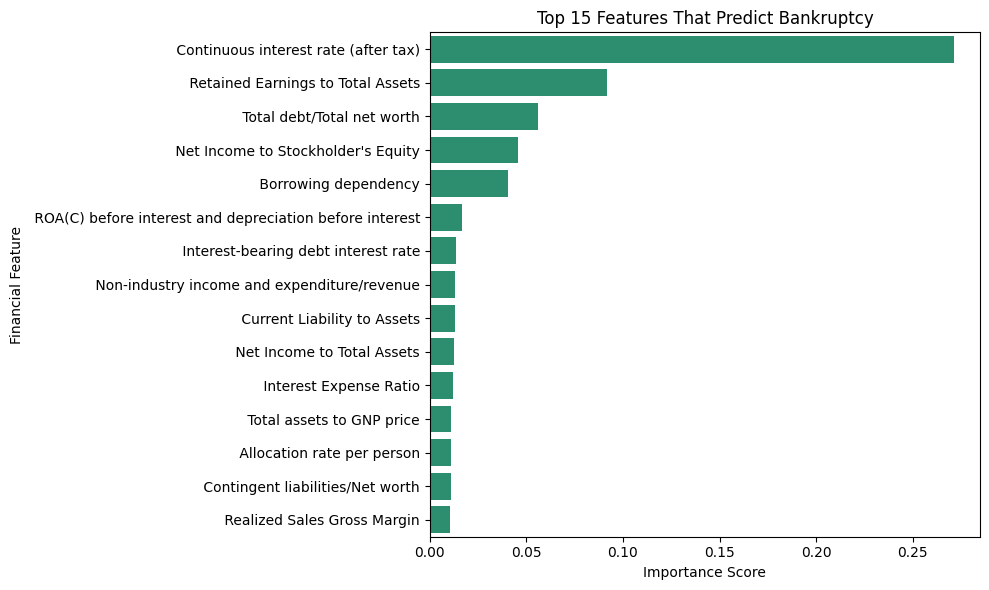

Top 3 most important features:
 -  Continuous interest rate (after tax) : 0.2712
 -  Retained Earnings to Total Assets : 0.0915
 -  Total debt/Total net worth : 0.0561


In [40]:
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=importance, color='#1D9E75')
plt.title('Top 15 Features That Predict Bankruptcy')
plt.xlabel('Importance Score')
plt.ylabel('Financial Feature')
plt.tight_layout()
plt.savefig('../dashboards/feature_importance.png', dpi=150)
plt.show()

print("Top 3 most important features:")
for i, row in importance.head(3).iterrows():
    print(" -", row['feature'], ":", round(row['importance'], 4))

In [41]:
import os
os.makedirs('../dashboards', exist_ok=True)

pio.write_html(fig, '../dashboards/financial_dashboard.html')

print("Dashboard saved successfully!")
print("Location: dashboards/financial_dashboard.html")
print("Open that file in any browser to see your full dashboard!")

Dashboard saved successfully!
Location: dashboards/financial_dashboard.html
Open that file in any browser to see your full dashboard!
